In [1]:
from arch import arch_model

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import warnings as _warnings


import sys
from pathlib import Path
repo_root = Path.cwd()
sys.path.append(str(repo_root.parent))

from config.plot_config import plot_config
output = plot_config() / "task3"
output.mkdir(exist_ok=True)


/Users/petterollinen/venvs/py314/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from helpers import DataAnalysis
analysis = DataAnalysis.from_csv("spiff_data-2.csv").clean()
prices = analysis.prices
gap_table = analysis.gap_table()
trailing_gaps = gap_table[gap_table["gap_type"] == "trailing"].copy()
log_return_data=analysis.log_returns

In [3]:
trailing_gaps

,series,start,end,length,gap_type
1,gurkor,5257,5456,200,trailing
3,guitars,5257,5456,200,trailing
5,slingshots,5257,5456,200,trailing
7,stocks,5257,5456,200,trailing
9,sugar,5257,5456,200,trailing
11,water,5257,5456,200,trailing
13,tranquillity,5257,5456,200,trailing


## Trailing Gap Extrapolation

Unlike the internal gaps in task 2, trailing gaps have **no right endpoint** — there is nothing to pin paths to. This means we cannot use a Brownian bridge; instead we do a pure forward extrapolation from the last observed price.

### GARCH(1,1)-t Extrapolation

**Pipeline**

1. Fit a GARCH(1,1) model with Student-t innovations on the `calibration_window` log-returns immediately preceding the gap. This captures both the current volatility level and any volatility clustering.
2. Use the fitted model to forecast the conditional variance for each of the `n_steps` ahead — variance is highest near the gap start (where clustering state is known) and mean-reverts toward the unconditional level over the horizon.
3. Draw `n_simulations` paths: at each step, sample a Student-t innovation (unit variance), scale it by the forecasted conditional standard deviation, and accumulate in log-price space.
4. Summarise with a median path and percentile bands.

Because there is no target endpoint, uncertainty fans out monotonically — the bands widen with the square-root of time, modulated by the GARCH mean-reversion.

In [4]:
def garch_extrapolation(
    price_series: pd.Series,
    start_day,
    n_steps: int,
    calibration_window: int = 120,
    n_simulations: int = 1000,
    random_seed: int | None = None,
) -> dict:
    """
    Extrapolate a trailing gap using a GARCH(1,1)-t forward simulation.

    No right endpoint is available, so paths fan out freely from the last
    observed price. The GARCH(1,1) conditional variance forecast mean-reverts
    toward the unconditional level over the horizon, producing a widening but
    decelerating uncertainty cone.

    Parameters
    ----------
    price_series : pd.Series
        Observed prices up to (but not including) start_day.
    start_day :
        First index label of the gap (first missing observation).
    n_steps : int
        Number of steps to extrapolate (gap length).
    calibration_window : int
        Number of pre-gap log-returns used to fit the GARCH model.
    n_simulations : int
        Number of Monte Carlo paths.
    random_seed : int or None
        Fix for reproducibility.

    Returns
    -------
    dict with keys:
        gap_index, median, mean, std, percentiles (DataFrame),
        simulations, full_series, nu, method
    """
    MIN_OBS = 20
    rng    = np.random.default_rng(random_seed)
    series = price_series.sort_index().dropna().copy()

    pre = series[series.index < start_day]
    if len(pre) == 0:
        raise ValueError("No observations before start_day.")

    anchor_price = float(pre.iloc[-1])

    # ── 1. Log-returns for calibration ────────────────────────────────────
    log_rets = np.log(pre / pre.shift(1)).dropna().iloc[-calibration_window:]
    if len(log_rets) < MIN_OBS:
        raise ValueError(
            f"Need ≥{MIN_OBS} pre-gap log-returns, got {len(log_rets)}."
        )

    # ── 2. Fit GARCH(1,1)-t ───────────────────────────────────────────────
    with _warnings.catch_warnings():
        _warnings.simplefilter("ignore")
        model  = arch_model(log_rets.values * 100, mean="Zero",
                            vol="GARCH", p=1, q=1,
                            dist="StudentsT", rescale=False)
        result = model.fit(disp="off", show_warning=False)

    _p = result.params
    nu = float(_p.get("nu", 8.0))
    try:
        alpha = float(_p["alpha[1]"])
        beta  = float(_p["beta[1]"])
    except KeyError:
        # fallback: find any param whose name contains alpha / beta
        alpha = next((float(v) for k, v in _p.items() if "alpha" in k.lower()), np.nan)
        beta  = next((float(v) for k, v in _p.items() if "beta"  in k.lower()), np.nan)
    if not (np.isfinite(nu) and nu > 2.05):
        nu = 8.0

    # ── 3. Forecast conditional variances for n_steps ahead ───────────────
    fc        = result.forecast(horizon=n_steps, reindex=False)
    variances = fc.variance.iloc[-1].to_numpy(dtype=float) / 1e4  # back to r² units

    if not np.isfinite(variances).all() or np.any(variances <= 0):
        # Fallback: constant variance from sample std
        variances = np.full(n_steps, float(log_rets.std()) ** 2)

    # ── 4. Build gap index ────────────────────────────────────────────────
    gap_index = pd.RangeIndex(start=int(start_day), stop=int(start_day) + n_steps)

    # ── 5. Simulate paths with Student-t innovations ──────────────────────
    # z ~ t_ν (unit variance), scaled by sqrt(h-step conditional variance)
    dof    = nu
    z      = (rng.standard_t(dof, size=(n_simulations, n_steps))
               * np.sqrt((dof - 2.0) / dof))
    shocks = z * np.sqrt(variances)[None, :]        # (n_sims, n_steps)

    log_paths = np.log(anchor_price) + np.cumsum(shocks, axis=1)
    paths     = np.exp(log_paths)                   # (n_sims, n_steps)

    # ── 6. Summarise ──────────────────────────────────────────────────────
    median_path = np.median(paths, axis=0)
    mean_path   = np.mean(paths,   axis=0)
    std_path    = np.std(paths,    axis=0)

    pct_values  = np.percentile(paths, [5, 25, 50, 75, 95], axis=0)
    percentiles = pd.DataFrame(
        pct_values.T,
        index=gap_index,
        columns=["p5", "p25", "p50", "p75", "p95"],
    )

    gap_fill    = pd.Series(median_path, index=gap_index, name=series.name)
    full_series = pd.concat([series, gap_fill]).sort_index()

    return {
        "method":      "garch_extrapolation",
        "gap_index":   gap_index,
        "median":      median_path,
        "mean":        mean_path,
        "std":         std_path,
        "percentiles": percentiles,
        "simulations": paths,
        "full_series": full_series,
        "nu":          nu,
        "alpha":       alpha,
        "beta":        beta,
        "variances":   variances,
    }


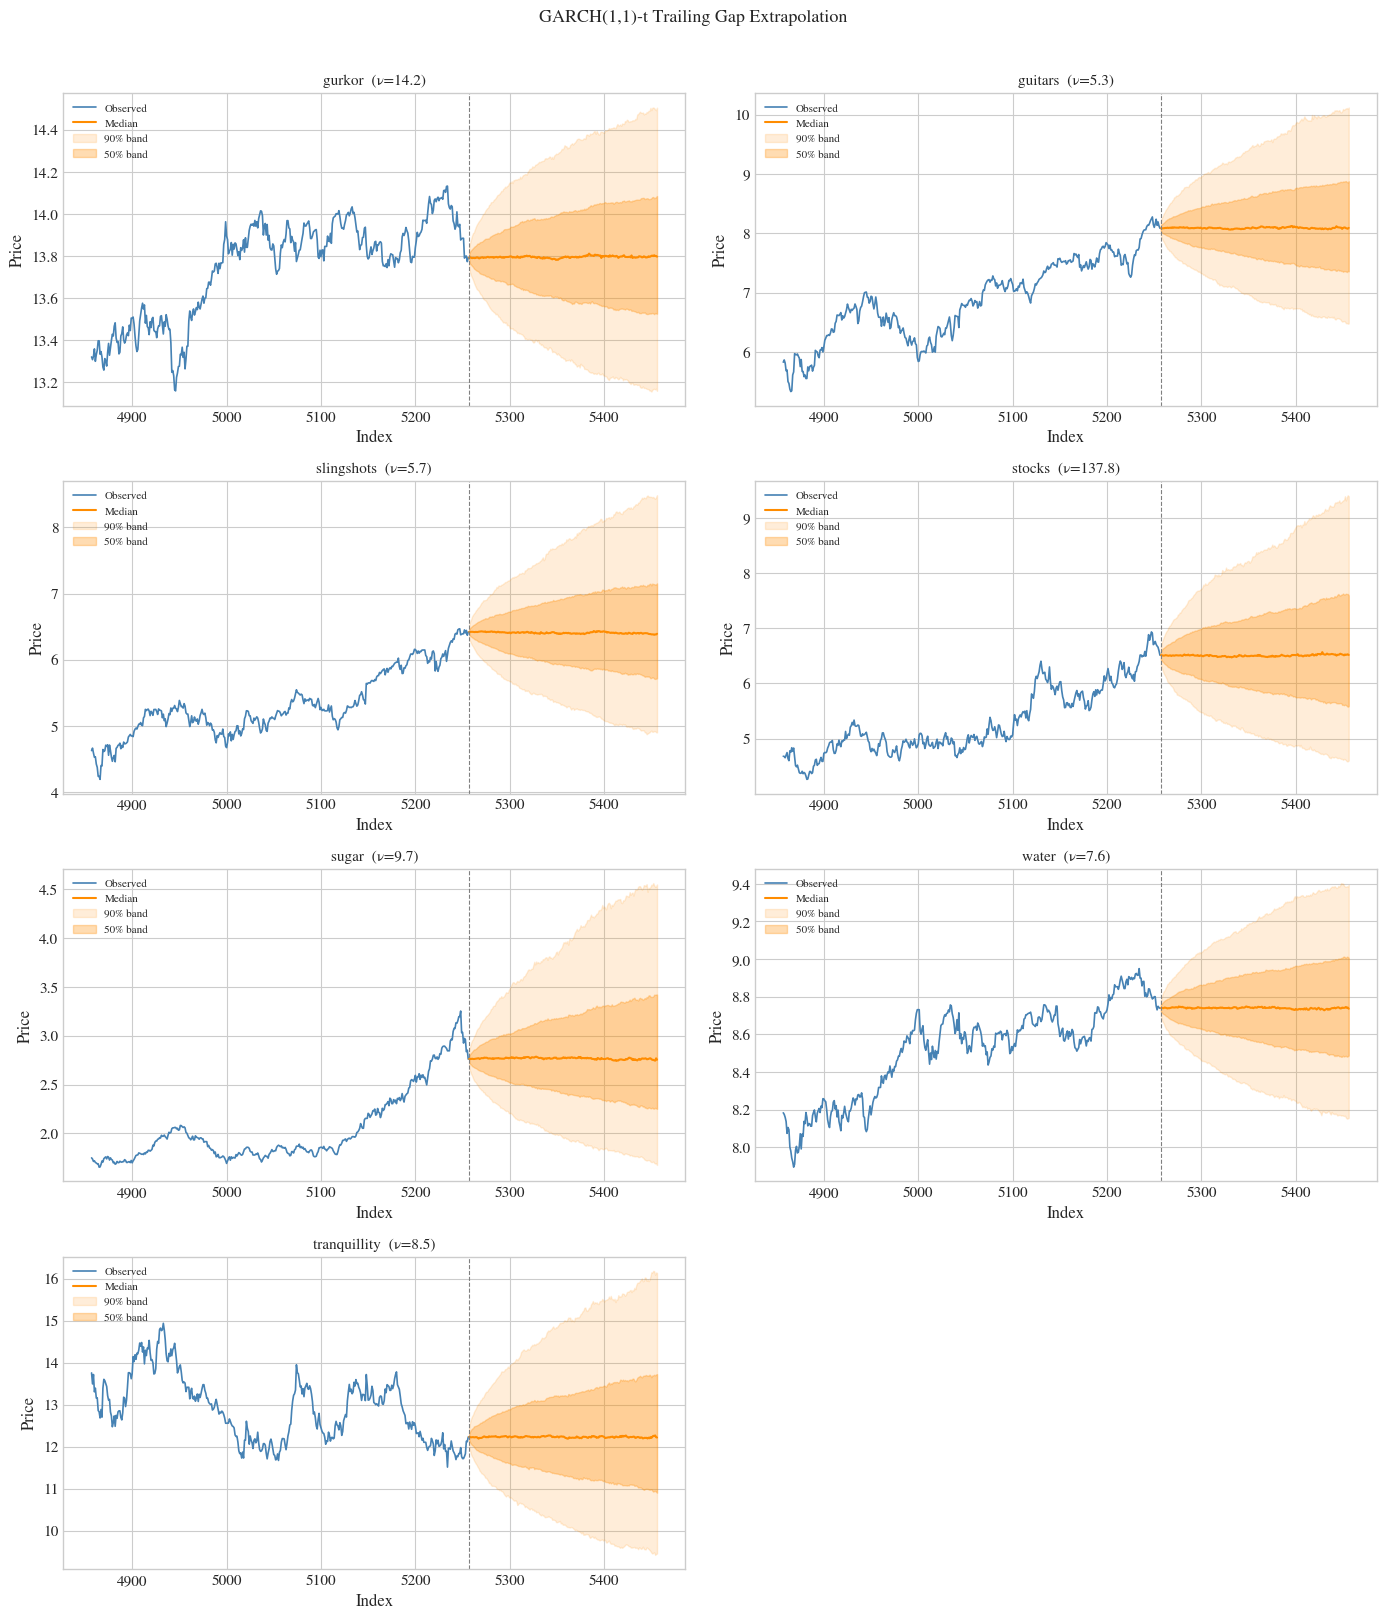

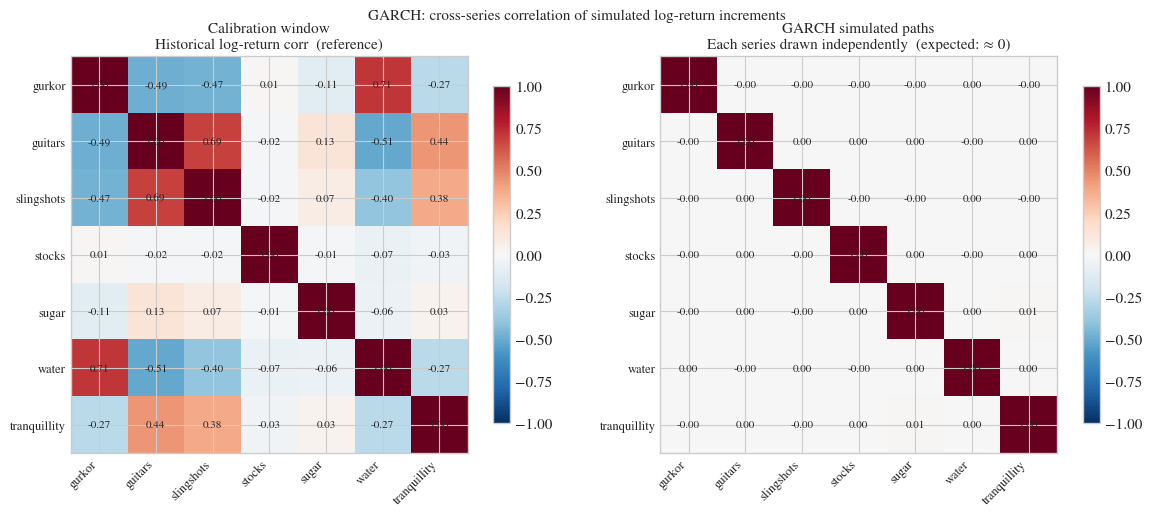

In [5]:
HISTORY_WINDOW = 400   # observed days to show left of the gap
N_COLS = 2
n_series = len(trailing_gaps)
n_rows   = (n_series + N_COLS - 1) // N_COLS

fig, axes = plt.subplots(n_rows, N_COLS, figsize=(14, 4 * n_rows))
axes = axes.flatten()

results = {}
for ax, (_, row) in zip(axes, trailing_gaps.iterrows()):
    name      = row["series"]
    start_day = row["start"]
    n_steps   = row["length"]

    res = garch_extrapolation(
        prices[name],
        start_day=start_day,
        n_steps=n_steps,
        calibration_window=400,
        n_simulations=2000,
        random_seed=42,
    )
    results[name] = res

    pct      = res["percentiles"]
    gap_idx  = res["gap_index"]
    obs_tail = prices[name].dropna().iloc[-HISTORY_WINDOW:]

    ax.plot(obs_tail.index, obs_tail.values, color="steelblue", lw=1.2, label="Observed")
    ax.plot(gap_idx, res["median"],  color="darkorange", lw=1.5, label="Median")
    ax.fill_between(gap_idx, pct["p5"],  pct["p95"], alpha=0.15, color="darkorange", label="90% band")
    ax.fill_between(gap_idx, pct["p25"], pct["p75"], alpha=0.30, color="darkorange", label="50% band")
    ax.axvline(x=start_day, color="grey", lw=0.8, ls="--")
    ax.set_title(f"{name}  (ν={res['nu']:.1f})", fontsize=11)
    ax.set_xlabel("Index")
    ax.set_ylabel("Price")
    ax.legend(fontsize=8)

for ax in axes[n_series:]:
    ax.set_visible(False)

fig.suptitle("GARCH(1,1)-t Trailing Gap Extrapolation", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ── Shared helpers (also used by DCC cell) ────────────────────────────────
def simulated_path_corr(sim_results, snames):
    """Cross-series Pearson corr of step-wise log-return increments, pooled across simulations."""
    lr_flat = []
    for s in snames:
        paths = sim_results[s]["simulations"]       # (n_sims, n_steps)
        lr    = np.diff(np.log(paths), axis=1)      # (n_sims, n_steps-1)
        lr_flat.append(lr.reshape(-1))
    return np.corrcoef(np.stack(lr_flat, axis=0))

def draw_corr_heatmap(ax, mat, labels, title):
    k  = len(labels)
    im = ax.imshow(mat, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(k)); ax.set_yticks(range(k))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
    ax.set_yticklabels(labels, fontsize=9)
    for i in range(k):
        for j in range(k):
            ax.text(j, i, f"{mat[i, j]:.2f}", ha="center", va="center", fontsize=8)
    plt.colorbar(im, ax=ax, shrink=0.85)
    ax.set_title(title, fontsize=11)

# ── GARCH: correlation of simulated paths vs calibration window ───────────
garch_series = list(results.keys())
_ref_start   = trailing_gaps.iloc[0]["start"]

all_lr_hist = np.log(prices / prices.shift(1))
cal_returns = all_lr_hist[all_lr_hist.index < _ref_start].dropna().iloc[-400:]
cal_corr    = np.corrcoef(cal_returns[garch_series].values.T)
garch_sim_corr = simulated_path_corr(results, garch_series)

fig_g, axes_g = plt.subplots(1, 2, figsize=(12, 5))
draw_corr_heatmap(axes_g[0], cal_corr,       garch_series,
                  "Calibration window\nHistorical log-return corr  (reference)")
draw_corr_heatmap(axes_g[1], garch_sim_corr, garch_series,
                  "GARCH simulated paths\nEach series drawn independently  (expected: ≈ 0)")
fig_g.suptitle("GARCH: cross-series correlation of simulated log-return increments", fontsize=11)
plt.tight_layout()
plt.show()

### DCC-GARCH(1,1) Joint Extrapolation

Extends the univariate method by modelling all series **simultaneously**, so simulated paths respect the cross-series correlation structure observed before the gap.

**Pipeline**

1. **Univariate GARCH(1,1)-t per series** — same as above; produces per-series conditional variance forecasts and a matrix of standardised residuals `Z`.
2. **DCC(1,1) on `Z`** — the unconditional correlation `Q̄ = ZᵀZ / T` is estimated, then DCC parameters `(a, b)` are fit by quasi-MLE. The last filtered state `Q_T` captures the correlation regime at the end of the observed window.
3. **Analytic DCC forecast** — `Q_{T+h} = Q̄ + (a+b)ʰ (Q_T − Q̄)`. Correlations decay toward the unconditional mean as the horizon grows.
4. **Correlated simulation** — at each step `h`, the Cholesky factor of `R_h` (normalised `Q_{T+h}`) transforms independent standard normals into correlated innovations; each is then scaled by its series' GARCH conditional standard deviation.
5. Results are packaged per series in the same format as `garch_extrapolation`.

In [6]:
from scipy.optimize import minimize
from scipy.stats import norm as _snorm, t as _st


def dcc_garch_extrapolation(
    prices_df: pd.DataFrame,
    start_day,
    n_steps: int,
    calibration_window: int = 120,
    n_simulations: int = 1000,
    random_seed: int | None = None,
) -> tuple[dict[str, dict], dict]:
    """
    Extrapolate all series jointly using DCC-GARCH(1,1)-t.

    Univariate GARCH(1,1)-t handles each series' marginal volatility dynamics.
    DCC(1,1) is fit on the matrix of standardised residuals to capture
    time-varying cross-series correlations.  At each forecast step the
    DCC-predicted correlation matrix is used to draw correlated Student-t
    innovations (Gaussian copula with per-series t_ν_i marginals), which are
    then scaled by the per-series GARCH conditional standard deviations.

    Parameters
    ----------
    prices_df : pd.DataFrame
        Full price matrix; columns are series names.
    start_day :
        First index label of the trailing gap.
    n_steps : int
        Gap length to extrapolate.
    calibration_window : int
        Pre-gap log-returns used for both GARCH and DCC calibration.
    n_simulations : int
        Monte Carlo paths per series (paths are drawn jointly).
    random_seed : int or None

    Returns
    -------
    results : dict[str, dict]
        Per-series results matching the garch_extrapolation output format.
    model_info : dict
        DCC parameters (a, b), Q_bar, Q_T, persistence, per-series GARCH info.
    """
    MIN_OBS = 30
    rng          = np.random.default_rng(random_seed)
    series_names = list(prices_df.columns)
    k            = len(series_names)

    # ── 1. Calibration log-returns ────────────────────────────────────────
    all_lr  = np.log(prices_df / prices_df.shift(1))
    cal_pre = (
        all_lr[all_lr.index < start_day]
        .dropna()
        .iloc[-calibration_window:]
    )
    if len(cal_pre) < MIN_OBS:
        raise ValueError(
            f"Need ≥{MIN_OBS} calibration observations, got {len(cal_pre)}."
        )
    n_cal = len(cal_pre)

    # ── 2. Univariate GARCH(1,1)-t per series ────────────────────────────
    def fit_garch_params(returns: np.ndarray, series_name: str = "?"):
        var      = float(np.var(returns)) or 1e-8
        fallback = (0.05 * var, 0.10, 0.85, 8.0, np.full(len(returns), var))

        # Only catch numeric/optimization failures; let unexpected bugs propagate.
        try:
            with _warnings.catch_warnings():
                _warnings.simplefilter("ignore")
                res = arch_model(
                    returns * 100, mean="Zero", vol="GARCH",
                    p=1, q=1, dist="StudentsT", rescale=False,
                ).fit(disp="off", show_warning=False)
        except (ValueError, np.linalg.LinAlgError, FloatingPointError) as exc:
            _warnings.warn(
                f"GARCH fit failed for '{series_name}': {exc}; "
                "using constant-variance fallback",
                RuntimeWarning, stacklevel=2,
            )
            return fallback
        # AttributeError, TypeError, etc. are NOT caught here — they propagate.

        # arch reports non-convergence via a flag, not an exception.
        if res.convergence_flag != 0:
            _warnings.warn(
                f"GARCH non-convergence for '{series_name}' "
                f"(convergence_flag={res.convergence_flag}); "
                "using constant-variance fallback",
                RuntimeWarning, stacklevel=2,
            )
            return fallback

        omega = float(res.params["omega"]) / 1e4
        alpha = float(res.params["alpha[1]"])
        beta  = float(res.params["beta[1]"])
        nu    = float(res.params.get("nu", 8.0))
        # BUG FIX: arch returns conditional_volatility as numpy.ndarray (not
        # pandas.Series), so .values raises AttributeError.  Use np.asarray().
        s2    = np.asarray(res.conditional_volatility) ** 2 / 1e4
        if (not np.isfinite([omega, alpha, beta]).all()
                or any(x < 0 for x in (omega, alpha, beta))
                or alpha + beta >= 1.0
                or not np.isfinite(s2).all()
                or (s2 <= 0).any()):
            return fallback
        return omega, alpha, beta, nu, s2

    garch_info = {}
    std_Z      = np.zeros((n_cal, k))

    for idx, s in enumerate(series_names):
        omega, alpha, beta, nu, s2 = fit_garch_params(cal_pre[s].values, series_name=s)
        garch_info[s] = dict(
            omega=omega, alpha=alpha, beta=beta, nu=nu,
            last_s2=float(s2[-1]),
            last_r2=float(cal_pre[s].values[-1] ** 2),
        )
        std_Z[:, idx] = np.clip(cal_pre[s].values / np.sqrt(s2), -6.0, 6.0)

    # ── 3. DCC(1,1) QMLE on standardised residuals ───────────────────────
    Q_bar = std_Z.T @ std_Z / n_cal
    d_bar = np.sqrt(np.maximum(np.diag(Q_bar), 1e-10))
    Q_bar_cor = Q_bar / np.outer(d_bar, d_bar)
    np.fill_diagonal(Q_bar_cor, 1.0)
    np.clip(Q_bar_cor, -0.9999, 0.9999, out=Q_bar_cor)
    np.fill_diagonal(Q_bar_cor, 1.0)

    def dcc_neg_loglik(params):
        a, b = params
        if a <= 0 or b <= 0 or a + b >= 1.0:
            return 1e12
        Q  = Q_bar_cor.copy()
        ll = 0.0
        for t in range(n_cal):
            z  = std_Z[t]
            dq = np.sqrt(np.maximum(np.diag(Q), 1e-10))
            R  = Q / np.outer(dq, dq)
            np.fill_diagonal(R, 1.0)
            try:
                sign, logdet = np.linalg.slogdet(R)
                if sign <= 0 or not np.isfinite(logdet):
                    return 1e12
                Rinvz = np.linalg.solve(R, z)
                if not np.isfinite(Rinvz).all():
                    return 1e12
                ll += logdet + z @ Rinvz - z @ z
            except np.linalg.LinAlgError:
                return 1e12
            Q = (1 - a - b) * Q_bar_cor + a * np.outer(z, z) + b * Q
        return 0.5 * ll if np.isfinite(ll) else 1e12

    # Multi-start to avoid the shallow b=0 local trap.
    # The LL ridge toward high b can be < 2 nats — a single start misses it.
    _best_val, _best_x = np.inf, np.array([0.05, 0.90])
    for _a0, _b0 in [(0.05, 0.90), (0.02, 0.95), (0.01, 0.50), (0.10, 0.70)]:
        if _a0 + _b0 >= 1.0:
            continue
        _r = minimize(
            dcc_neg_loglik, x0=[_a0, _b0],
            method="L-BFGS-B",
            bounds=[(1e-6, 0.30), (1e-6, 0.999)],
            options={"maxiter": 300},
        )
        if _r.fun < _best_val and float(_r.x[0]) + float(_r.x[1]) < 1.0:
            _best_val, _best_x = _r.fun, _r.x
    if np.isfinite(_best_val):
        a_dcc, b_dcc = float(_best_x[0]), float(_best_x[1])
    else:
        a_dcc, b_dcc = 0.05, 0.90
    persistence = a_dcc + b_dcc

    # ── 4. Q_T: last filtered DCC state ──────────────────────────────────
    Q_T = Q_bar_cor.copy()
    for t in range(n_cal):
        z   = std_Z[t]
        Q_T = (1 - a_dcc - b_dcc) * Q_bar_cor + a_dcc * np.outer(z, z) + b_dcc * Q_T
    if not np.isfinite(Q_T).all():
        Q_T = Q_bar_cor.copy()

    # ── 5. GARCH h-step variance forecasts per series ─────────────────────
    def garch_forecast(p: dict, h: int) -> np.ndarray:
        omega, alpha, beta = p["omega"], p["alpha"], p["beta"]
        s2, r2 = p["last_s2"], p["last_r2"]
        out = np.zeros(h)
        for i in range(h):
            s2 = omega + alpha * r2 + beta * s2
            if not (np.isfinite(s2) and s2 > 0):
                s2 = p["last_s2"]
            out[i] = s2
            r2 = s2
        return out

    # garch_sigmas[series_idx, step]
    garch_sigmas = np.zeros((k, n_steps))
    for idx, s in enumerate(series_names):
        fv = garch_forecast(garch_info[s], n_steps)
        garch_sigmas[idx] = np.sqrt(np.maximum(fv, 1e-12))

    # Per-series degrees of freedom and unit-variance t scale factors
    nu_arr  = np.array([garch_info[s]["nu"] for s in series_names])  # (k,)
    t_scale = np.sqrt((nu_arr - 2.0) / nu_arr)                       # (k,)

    # ── 6. Anchor log-prices ──────────────────────────────────────────────
    anchor_logs = np.zeros(k)
    for idx, s in enumerate(series_names):
        obs = prices_df[s].dropna()
        anchor_logs[idx] = np.log(float(obs[obs.index < start_day].iloc[-1]))

    # ── 7. Simulate correlated paths ──────────────────────────────────────
    # increments shape: (n_sims, n_steps, k)
    increments = np.zeros((n_simulations, n_steps, k))

    for h in range(n_steps):
        # Analytic DCC forecast: Q̄ + persistence^h (Q_T - Q̄)
        decay = persistence ** (h + 1)
        Q_h   = Q_bar_cor + decay * (Q_T - Q_bar_cor)
        dq    = np.sqrt(np.maximum(np.diag(Q_h), 1e-10))
        R_h   = Q_h / np.outer(dq, dq)
        np.fill_diagonal(R_h, 1.0)
        np.clip(R_h, -0.9999, 0.9999, out=R_h)
        np.fill_diagonal(R_h, 1.0)

        # Cholesky; project to nearest PD on failure
        try:
            L_h = np.linalg.cholesky(R_h)
        except np.linalg.LinAlgError:
            eigvals, eigvecs = np.linalg.eigh(R_h)
            eigvals = np.maximum(eigvals, 1e-8)
            R_h = eigvecs @ np.diag(eigvals) @ eigvecs.T
            d   = np.sqrt(np.diag(R_h))
            R_h = R_h / np.outer(d, d)
            np.fill_diagonal(R_h, 1.0)
            L_h = np.linalg.cholesky(R_h)

        # Gaussian copula with t_ν_i marginals per series:
        # 1. Correlated N(0,1) via Cholesky of DCC correlation matrix
        # 2. Map each series N(0,1) → t_ν_i(unit var) via probability integral transform
        #    so each series' innovation matches its univariate GARCH distribution exactly.
        eps     = rng.standard_normal((n_simulations, k))
        z_gauss = eps @ L_h.T                                           # (n_sims, k)
        u       = _snorm.cdf(z_gauss)                                   # uniform margins
        np.clip(u, 1e-10, 1 - 1e-10, out=u)
        z = _st.ppf(u, df=nu_arr[None, :]) * t_scale[None, :]           # (n_sims, k)

        increments[:, h, :] = z * garch_sigmas[:, h][None, :]

    cum_inc   = np.cumsum(increments, axis=1)                # (n_sims, n_steps, k)
    log_paths = anchor_logs[None, None, :] + cum_inc
    paths     = np.exp(log_paths)                            # (n_sims, n_steps, k)

    # ── 8. Package per-series results ─────────────────────────────────────
    gap_index = pd.RangeIndex(start=int(start_day), stop=int(start_day) + n_steps)
    results   = {}

    for idx, s in enumerate(series_names):
        p           = paths[:, :, idx]                       # (n_sims, n_steps)
        median_path = np.median(p, axis=0)
        mean_path   = np.mean(p,   axis=0)
        std_path    = np.std(p,    axis=0)
        pct_values  = np.percentile(p, [5, 25, 50, 75, 95], axis=0)
        percentiles = pd.DataFrame(
            pct_values.T, index=gap_index,
            columns=["p5", "p25", "p50", "p75", "p95"],
        )
        obs         = prices_df[s].dropna()
        obs         = obs[obs.index < start_day]
        gap_fill    = pd.Series(median_path, index=gap_index, name=s)
        full_series = pd.concat([obs, gap_fill]).sort_index()

        results[s] = {
            "method":      "dcc_garch_extrapolation",
            "gap_index":   gap_index,
            "median":      median_path,
            "mean":        mean_path,
            "std":         std_path,
            "percentiles": percentiles,
            "simulations": p,
            "full_series": full_series,
            "nu":          garch_info[s]["nu"],
            "alpha":       garch_info[s]["alpha"],
            "beta":        garch_info[s]["beta"],
            "dcc_a":       a_dcc,
            "dcc_b":       b_dcc,
        }

    model_info = {
        "dcc_a":       a_dcc,
        "dcc_b":       b_dcc,
        "persistence": persistence,
        "Q_bar":       Q_bar_cor,
        "Q_T":         Q_T,
        "garch_info":  garch_info,
    }
    return results, model_info

DCC a=0.0176  b=0.8355  persistence=0.8531

Per-series GARCH ν (degrees of freedom):
  gurkor         ν=14.17  α=0.000  β=0.999
  guitars        ν=5.29  α=0.040  β=0.946
  slingshots     ν=5.69  α=0.104  β=0.814
  stocks         ν=137.81  α=0.020  β=0.000
  sugar          ν=8.00  α=0.100  β=0.850
  water          ν=7.62  α=0.030  β=0.957
  tranquillity   ν=8.52  α=0.027  β=0.942


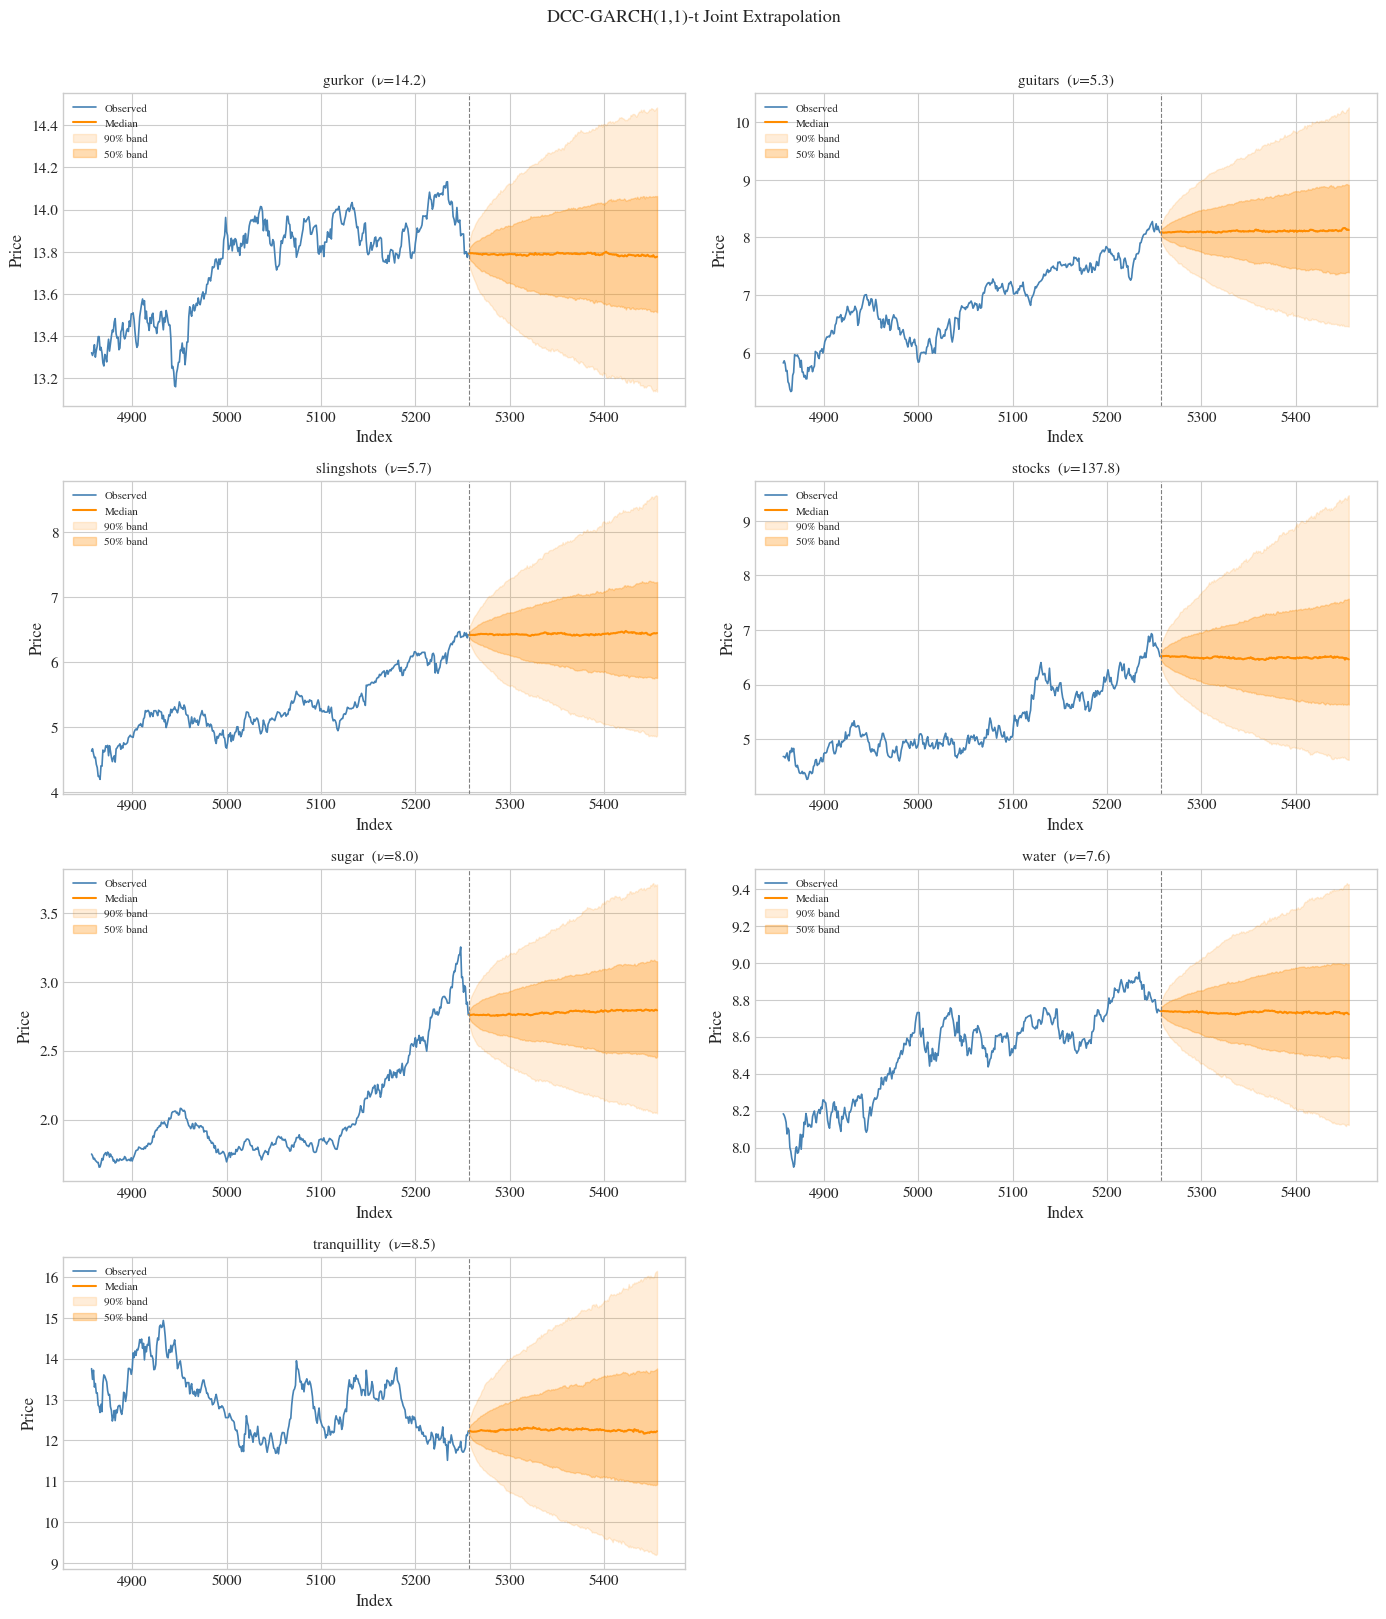

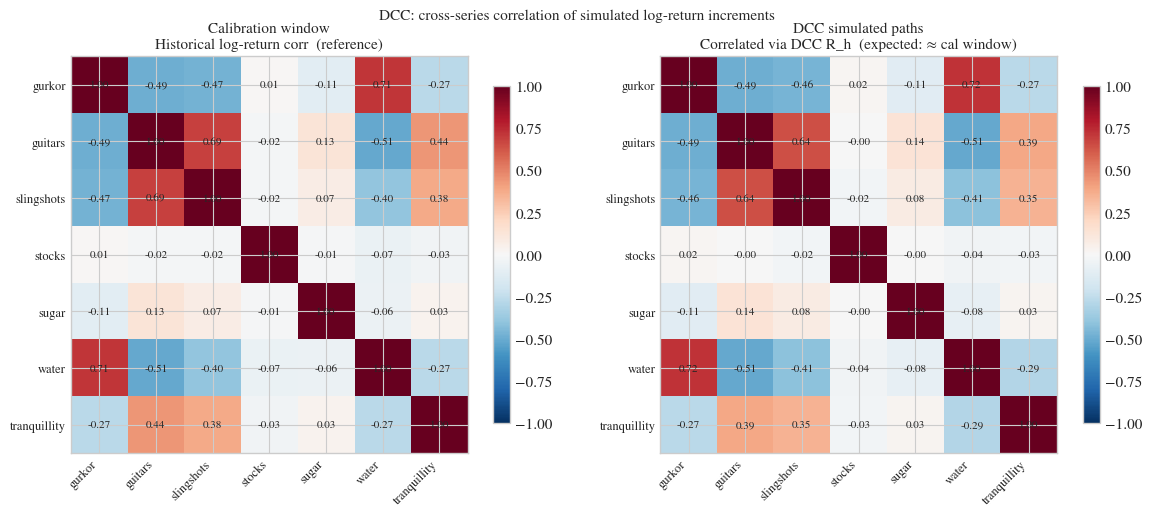

In [7]:
row0         = trailing_gaps.iloc[0]
start_day    = row0["start"]
n_steps      = row0["length"]

dcc_results, model_info = dcc_garch_extrapolation(
    prices,
    start_day=start_day,
    n_steps=n_steps,
    calibration_window=400,
    n_simulations=2000,
    random_seed=42,
)

print(f"DCC a={model_info['dcc_a']:.4f}  b={model_info['dcc_b']:.4f}  "
      f"persistence={model_info['persistence']:.4f}")
print("\nPer-series GARCH ν (degrees of freedom):")
for s, info in model_info["garch_info"].items():
    print(f"  {s:<14} ν={info['nu']:.2f}  α={info['alpha']:.3f}  β={info['beta']:.3f}")

# ── Fan plots ─────────────────────────────────────────────────────────────
HISTORY_WINDOW = 400
n_series = len(dcc_results)
N_COLS   = 2
n_rows   = (n_series + N_COLS - 1) // N_COLS

fig, axes = plt.subplots(n_rows, N_COLS, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for ax, (name, res) in zip(axes, dcc_results.items()):
    pct     = res["percentiles"]
    gap_idx = res["gap_index"]
    obs_tail = prices[name].dropna().iloc[-HISTORY_WINDOW:]

    ax.plot(obs_tail.index, obs_tail.values, color="steelblue", lw=1.2, label="Observed")
    ax.plot(gap_idx, res["median"],  color="darkorange", lw=1.5, label="Median")
    ax.fill_between(gap_idx, pct["p5"],  pct["p95"], alpha=0.15, color="darkorange", label="90% band")
    ax.fill_between(gap_idx, pct["p25"], pct["p75"], alpha=0.30, color="darkorange", label="50% band")
    ax.axvline(x=start_day, color="grey", lw=0.8, ls="--")
    ax.set_title(f"{name}  (ν={res['nu']:.1f})", fontsize=11)
    ax.set_xlabel("Index")
    ax.set_ylabel("Price")
    ax.legend(fontsize=8)

for ax in axes[n_series:]:
    ax.set_visible(False)

fig.suptitle("DCC-GARCH(1,1)-t Joint Extrapolation", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ── DCC: correlation of simulated paths vs calibration window ─────────────
dcc_series = list(dcc_results.keys())

all_lr_hist = np.log(prices / prices.shift(1))
cal_returns = all_lr_hist[all_lr_hist.index < start_day].dropna().iloc[-400:]
cal_corr    = np.corrcoef(cal_returns[dcc_series].values.T)
dcc_sim_corr = simulated_path_corr(dcc_results, dcc_series)

fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))
draw_corr_heatmap(axes2[0], cal_corr,     dcc_series,
                  "Calibration window\nHistorical log-return corr  (reference)")
draw_corr_heatmap(axes2[1], dcc_sim_corr, dcc_series,
                  "DCC simulated paths\nCorrelated via DCC R_h  (expected: ≈ cal window)")
fig2.suptitle("DCC: cross-series correlation of simulated log-return increments", fontsize=11)
plt.tight_layout()
plt.show()

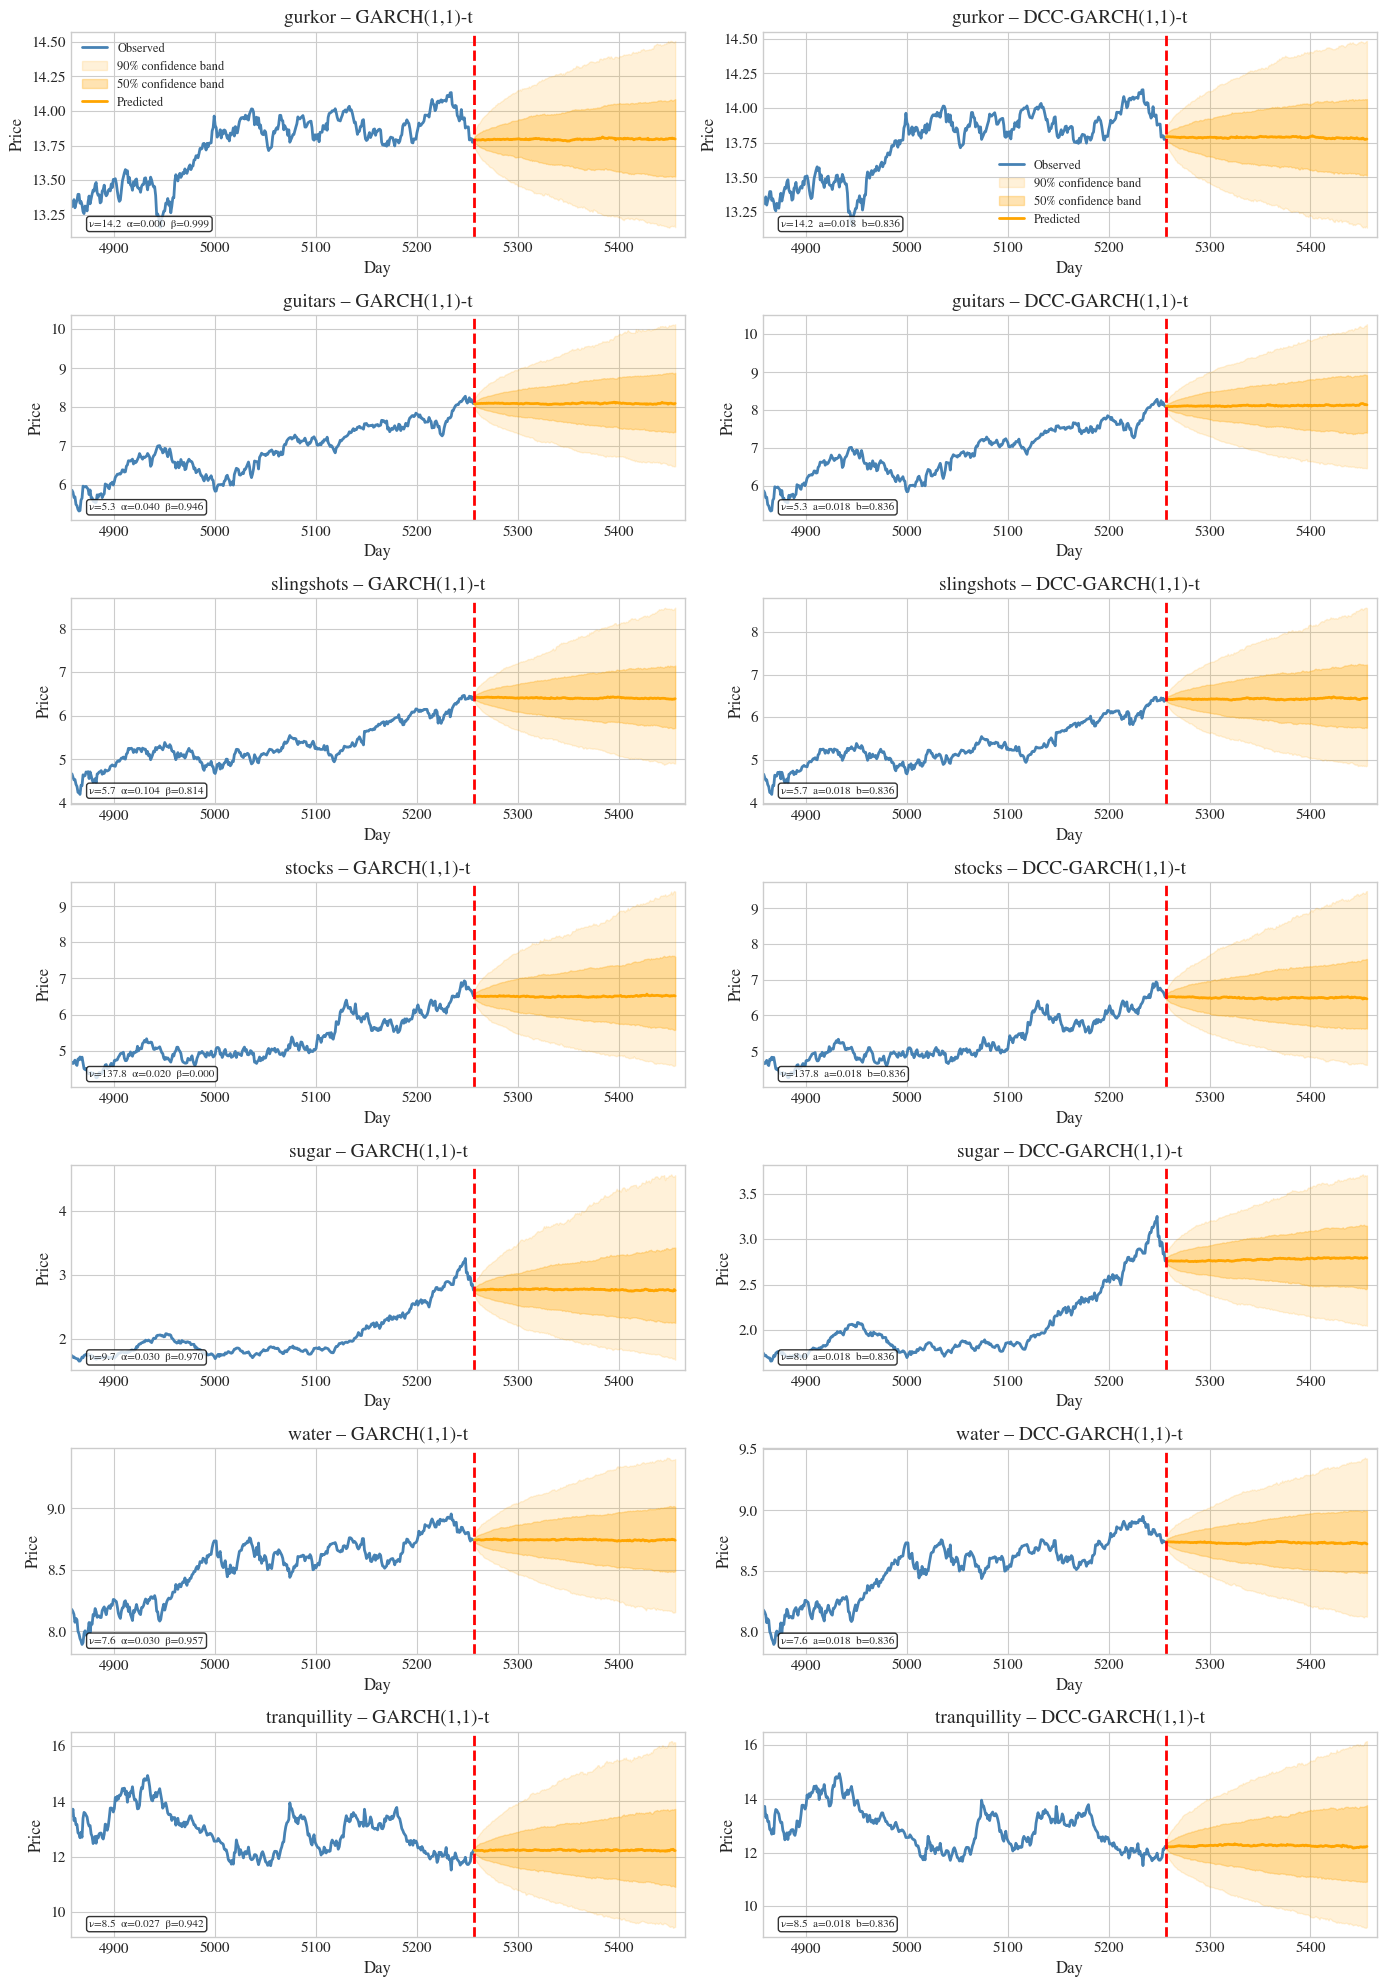

In [8]:


# ── Compute DCC for each series' own trailing gap ──────────────────────────
_starts  = trailing_gaps["start"].unique()
_lengths = trailing_gaps["length"].unique()

if len(_starts) == 1 and len(_lengths) == 1:
    _res_joint, _ = dcc_garch_extrapolation(
        prices,
        start_day=int(_starts[0]),
        n_steps=int(_lengths[0]),
        calibration_window=400,
        n_simulations=2000,
        random_seed=42,
    )
    dcc_all = {name: _res_joint[name] for name in trailing_gaps["series"]}
else:
    dcc_all = {}
    for _, row in tqdm(trailing_gaps.iterrows(), total=len(trailing_gaps), desc="DCC per series"):
        name = row["series"]
        _res, _ = dcc_garch_extrapolation(
            prices,
            start_day=int(row["start"]),
            n_steps=int(row["length"]),
            calibration_window=400,
            n_simulations=2000,
            random_seed=42,
        )
        dcc_all[name] = _res[name]

# ── 7x2 comparison plot ────────────────────────────────────────────────────
series_list = trailing_gaps["series"].tolist()
fig, axes = plt.subplots(7, 2, figsize=(14, 20))

for row_idx, name in enumerate(series_list):
    gap_row   = trailing_gaps[trailing_gaps["series"] == name].iloc[0]
    gap_start = int(gap_row["start"])
    n_steps   = int(gap_row["length"])

    for col_idx, (res, label) in enumerate([
        (results[name], "GARCH(1,1)-t"),
        (dcc_all[name], "DCC-GARCH(1,1)-t"),
    ]):
        ax      = axes[row_idx, col_idx]
        pct     = res["percentiles"]
        gap_idx = res["gap_index"]
        x_lo    = gap_start - HISTORY_WINDOW
        x_hi    = gap_idx[-1] + 10

        visible = prices[name].dropna()
        visible = visible[(visible.index >= x_lo) & (visible.index < gap_start)]

        ax.plot(visible.index, visible.values, color="steelblue", label="Observed")
        ax.fill_between(gap_idx, pct["p5"],  pct["p95"], alpha=0.15, color="orange", label="90% confidence band")
        ax.fill_between(gap_idx, pct["p25"], pct["p75"], alpha=0.30, color="orange", label="50% confidence band")
        ax.plot(gap_idx, res["median"], color="orange", label="Predicted")
        ax.axvline(x=gap_start,ls='--', c='r')
        ax.set_xlim(x_lo, x_hi)
        ax.set_title(f"{name} \u2013 {label}")
        ax.set_xlabel("Day")
        ax.set_ylabel("Price")
        if col_idx == 0:  # GARCH
            param_txt = (
                f"\u03bd={res['nu']:.1f}  "
                f"\u03b1={res.get('alpha', float('nan')):.3f}  "
                f"\u03b2={res.get('beta',  float('nan')):.3f}"
            )
        else:             # DCC-GARCH
            param_txt = (
                f"\u03bd={res['nu']:.1f}  "
                f"a={res.get('dcc_a', float('nan')):.3f}  "
                f"b={res.get('dcc_b', float('nan')):.3f}"
            )
        ax.annotate(
            param_txt,
            xy=(0.03, 0.04), xycoords="axes fraction",
            fontsize=8, va="bottom", ha="left",
            bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.8),
        )
        if row_idx == 0:
            ax.legend(fontsize=9)

plt.tight_layout()
fig.savefig(output / "task3_extrapolation_comparison.pdf", bbox_inches="tight")
plt.show()


## Backtesting

**Design**

Real trailing gaps have no ground truth, so performance is measured on *pseudo-gaps* cut from the observed region (index ≥ 1 500, past any real internal gaps).

For each randomly chosen start position `t`:
1. Treat the `n_steps` prices starting at `t` as the unknown gap.
2. Feed only the data strictly before `t` to the method — no information from `t` onward is used. Both functions already enforce this via `index < start_day`, so there is no leakage by construction.
3. Compare the predicted median path and percentile bands against the hidden true prices.

**Metrics** — same convention as task 2

| Metric | Meaning |
|---|---|
| MAPE (%) | Mean absolute percentage error of median path |
| RMSE | Absolute error (price units) |
| RMSE log | RMSE in log-price space |
| Coverage 90 / 50 | Fraction of true prices inside the 90% / 50% band |
| End width 90% | Width of 90% band at the final forecast step, as % of price |

`dcc_garch_extrapolation` fits jointly across all series at each backtest position, so its 30 runs produce results for all 7 series simultaneously.

In [9]:
def _extrapolation_metrics(true_prices: np.ndarray, result: dict) -> dict:
    """Scalar metrics for one pseudo-gap backtest."""
    median = result["median"]
    pct    = result["percentiles"]
    p5, p25, p75, p95 = (
        pct["p5"].values, pct["p25"].values,
        pct["p75"].values, pct["p95"].values,
    )
    mape     = float(np.mean(np.abs(median - true_prices) / true_prices) * 100)
    rmse     = float(np.sqrt(np.mean((median - true_prices) ** 2)))
    rmse_log = float(np.sqrt(np.mean((np.log(median) - np.log(true_prices)) ** 2)))
    cov90    = float(np.mean((true_prices >= p5)  & (true_prices <= p95)))
    cov50    = float(np.mean((true_prices >= p25) & (true_prices <= p75)))
    mid_end  = (p5[-1] + p95[-1]) / 2
    width90  = float((p95[-1] - p5[-1]) / mid_end * 100)
    return dict(
        mape_pct=mape, rmse=rmse, rmse_log=rmse_log,
        coverage_90=cov90, coverage_50=cov50, end_width_90_pct=width90,
    )


def compute_shared_starts(
    prices_df: pd.DataFrame,
    n_backtests: int,
    n_steps: int,
    start_min: int = 1500,
    random_seed: int = 42,
) -> np.ndarray:
    """Draw the shared backtest window starts used by both GARCH and DCC."""
    rng = np.random.default_rng(random_seed)
    min_last_obs = min(
        int(prices_df[s].dropna().index[-n_steps - 1]) for s in prices_df.columns
    )
    candidates = prices_df.index[
        (prices_df.index >= start_min) & (prices_df.index <= min_last_obs)
    ]
    if len(candidates) == 0:
        raise ValueError("No valid backtest positions in the requested range.")
    return np.sort(
        rng.choice(candidates, size=min(n_backtests, len(candidates)), replace=False)
    )


def backtest_fixed_starts(
    method,
    prices_df: pd.DataFrame,
    fixed_starts: np.ndarray,
    n_steps: int = 200,
    calibration_window: int = 400,
    random_seed: int = 42,
    **method_kwargs,
) -> pd.DataFrame:
    """Backtest a single-series method on pre-specified windows across all series."""
    rng  = np.random.default_rng(random_seed)
    rows = []
    for s in prices_df.columns:
        obs = prices_df[s].dropna()
        for start in fixed_starts:
            tp = obs[obs.index >= start].iloc[:n_steps].values
            if len(tp) < n_steps:
                continue
            try:
                res = method(
                    prices_df[s], start_day=int(start), n_steps=n_steps,
                    calibration_window=calibration_window, n_simulations=500,
                    random_seed=int(rng.integers(1_000_000)), **method_kwargs,
                )
                m = _extrapolation_metrics(tp, res)
                m["series"] = s
                rows.append(m)
            except Exception:
                pass
    df = pd.DataFrame(rows)
    metric_cols = ["mape_pct", "rmse", "rmse_log", "coverage_90", "coverage_50", "end_width_90_pct"]
    out = df.groupby("series")[metric_cols].mean()
    out["mape_max"] = df.groupby("series")["mape_pct"].max()
    return out


def backtest_dcc_extrapolation(
    prices_df: pd.DataFrame,
    fixed_starts: np.ndarray,
    n_steps: int = 200,
    calibration_window: int = 120,
    random_seed: int = 42,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Backtest dcc_garch_extrapolation on a pre-specified set of windows.

    Parameters
    ----------
    fixed_starts : np.ndarray
        Backtest start positions — must be the same array passed to
        backtest_fixed_starts so GARCH and DCC are compared fairly.

    Returns
    -------
    metrics_df : pd.DataFrame
        Per-series average metrics.
    dcc_params_df : pd.DataFrame
        Per-run DCC parameters: start, dcc_a, dcc_b, persistence.
    """
    rng          = np.random.default_rng(random_seed)
    series_names = list(prices_df.columns)
    chosen       = np.sort(fixed_starts)

    rows       = []
    param_rows = []
    for start in tqdm(chosen, desc="DCC backtest"):
        truth = {}
        skip  = False
        for s in series_names:
            obs = prices_df[s].dropna()
            tp  = obs[obs.index >= start].iloc[:n_steps].values
            if len(tp) < n_steps:
                skip = True; break
            truth[s] = tp
        if skip:
            continue
        try:
            dcc_res, info = dcc_garch_extrapolation(
                prices_df, start_day=int(start), n_steps=n_steps,
                calibration_window=calibration_window,
                n_simulations=500,
                random_seed=int(rng.integers(1_000_000)),
            )
            param_rows.append({
                "start":       int(start),
                "dcc_a":       info["dcc_a"],
                "dcc_b":       info["dcc_b"],
                "persistence": info["persistence"],
            })
            for s in series_names:
                m = _extrapolation_metrics(truth[s], dcc_res[s])
                m["series"] = s
                rows.append(m)
        except Exception:
            pass

    df = pd.DataFrame(rows)
    metric_cols = ["mape_pct", "rmse", "rmse_log", "coverage_90", "coverage_50", "end_width_90_pct"]
    out = df.groupby("series")[metric_cols].mean()
    out["mape_max"] = df.groupby("series")["mape_pct"].max()
    return out, pd.DataFrame(param_rows)

In [10]:
N_BACKTESTS = 50
N_STEPS     = 200
CAL_WINDOW  = 400

# Both methods use exactly the same 50 pseudo-gap windows.
shared_starts = compute_shared_starts(
    prices, n_backtests=N_BACKTESTS, n_steps=N_STEPS, start_min=1500, random_seed=42,
)
print(f"Shared backtest windows: {len(shared_starts)} positions, "
      f"range [{shared_starts[0]}, {shared_starts[-1]}]")

print("\nRunning GARCH backtest...")
garch_bt = backtest_fixed_starts(
    garch_extrapolation, prices, shared_starts,
    n_steps=N_STEPS, calibration_window=CAL_WINDOW, random_seed=42,
)

print("Running DCC-GARCH backtest...")
dcc_bt, dcc_params = backtest_dcc_extrapolation(
    prices, fixed_starts=shared_starts,
    n_steps=N_STEPS, calibration_window=CAL_WINDOW, random_seed=42,
)

# ── DCC parameter diagnostics ─────────────────────────────────────────────
print("\n=== DCC parameters across backtest runs ===")
print(dcc_params[["dcc_a", "dcc_b", "persistence"]].describe().round(4))
n_b_zero = (dcc_params["dcc_b"] < 1e-4).sum()
if n_b_zero > 0:
    print(f"\n  WARNING: b ≈ 0 in {n_b_zero}/{len(dcc_params)} runs "
          f"(optimizer hit lower bound — DCC fell back to constant correlation)")
else:
    print(f"\n  b > 0 in all {len(dcc_params)} runs.")
print()
display(dcc_params.round(4))

# ── Two-way comparison ────────────────────────────────────────────────────
combined = pd.concat([
    garch_bt[["mape_pct", "coverage_90", "end_width_90_pct"]].add_prefix("garch_"),
    dcc_bt  [["mape_pct", "coverage_90", "end_width_90_pct"]].add_prefix("dcc_"),
], axis=1)

print("\n=== MAPE (%) ===")
display(combined[["garch_mape_pct", "dcc_mape_pct"]].round(3))

print("\n=== Coverage 90% (target 0.90) ===")
display(combined[["garch_coverage_90", "dcc_coverage_90"]].round(3))

print("\n=== 90% band width (%) ===")
display(combined[["garch_end_width_90_pct", "dcc_end_width_90_pct"]].round(2))

print("\n=== Cross-series mean MAPE ===")
print(combined[["garch_mape_pct", "dcc_mape_pct"]].mean().round(3))

Shared backtest windows: 50 positions, range [1726, 4948]

Running GARCH backtest...
Running DCC-GARCH backtest...


DCC backtest: 100%|██████████| 50/50 [02:03<00:00,  2.46s/it]


=== DCC parameters across backtest runs ===
         dcc_a    dcc_b  persistence
count  50.0000  50.0000      50.0000
mean    0.0192   0.4929       0.5122
std     0.0081   0.3149       0.3121
min     0.0045   0.0000       0.0045
25%     0.0139   0.1532       0.1757
50%     0.0195   0.5687       0.5839
75%     0.0243   0.7653       0.7940
max     0.0386   0.9110       0.9266




,start,dcc_a,dcc_b,persistence
0,1726,0.0070,0.8993,0.9063
1,1741,0.0054,0.9029,0.9083
2,1802,0.0104,0.8594,0.8699
3,1813,0.0090,0.8792,0.8883
4,1826,0.0088,0.8639,0.8727
5,1831,0.0049,0.7549,0.7598
6,1951,0.0187,0.1450,0.1637
7,2086,0.0196,0.6970,0.7166
8,2144,0.0164,0.6590,0.6754
9,2208,0.0138,0.6758,0.6896



=== MAPE (%) ===


...


=== Coverage 90% (target 0.90) ===


,garch_coverage_90,dcc_coverage_90
series,,
guitars,0.865,0.862
gurkor,0.873,0.865
slingshots,0.911,0.906
stocks,0.914,0.919
sugar,0.876,0.876
tranquillity,0.865,0.859
water,0.815,0.799



=== 90% band width (%) ===


,garch_end_width_90_pct,dcc_end_width_90_pct
series,,
guitars,65.76,65.16
gurkor,19.42,19.10
slingshots,70.17,68.61
stocks,65.74,65.81
sugar,69.18,67.20
tranquillity,61.01,60.24
water,16.45,15.59



=== Cross-series mean MAPE ===
garch_mape_pct    9.346
dcc_mape_pct      9.365
dtype: float64


In [11]:
# Improvement of DCC over univariate GARCH.
# Error metrics (lower is better):  (garch - dcc) / garch × 100  → positive = DCC better
# Coverage (higher is better):       dcc - garch                  → positive = DCC better
# Band width (lower is better):      (garch - dcc) / garch × 100  → positive = DCC narrower

error_cols    = ["mape_pct", "rmse", "rmse_log", "end_width_90_pct"]
coverage_cols = ["coverage_90", "coverage_50"]

imp = pd.DataFrame(index=garch_bt.index)
for c in error_cols:
    imp[c] = (garch_bt[c] - dcc_bt[c]) / garch_bt[c] * 100
for c in coverage_cols:
    imp[c] = dcc_bt[c] - garch_bt[c]

imp.columns = (
    [f"{c}_improvement_pct" for c in error_cols]
    + [f"{c}_delta" for c in coverage_cols]
)

print("Positive = DCC better.  Error/width: % reduction.  Coverage: absolute change.\n")
display(imp.round(3))

print("\n=== Cross-series average ===")
display(imp.mean().round(3).to_frame("mean"))

Positive = DCC better.  Error/width: % reduction.  Coverage: absolute change.



,mape_pct_improvement_pct,rmse_improvement_pct,rmse_log_improvement_pct,end_width_90_pct_improvement_pct,coverage_90_delta,coverage_50_delta
series,,,,,,
guitars,-0.526,-0.386,-0.440,0.917,-0.003,0.004
gurkor,-0.075,-0.036,-0.059,1.661,-0.008,-0.010
slingshots,-0.257,-0.128,-0.310,2.231,-0.005,-0.007
stocks,1.055,0.927,0.964,-0.102,0.004,0.007
sugar,-0.658,-0.789,-0.625,2.854,0.000,-0.020
tranquillity,-0.395,0.115,-0.059,1.266,-0.006,-0.004
water,-0.983,-1.146,-0.933,5.232,-0.016,-0.014



=== Cross-series average ===


,mean
mape_pct_improvement_pct,-0.263
rmse_improvement_pct,-0.206
rmse_log_improvement_pct,-0.209
end_width_90_pct_improvement_pct,2.009
coverage_90_delta,-0.005
coverage_50_delta,-0.006


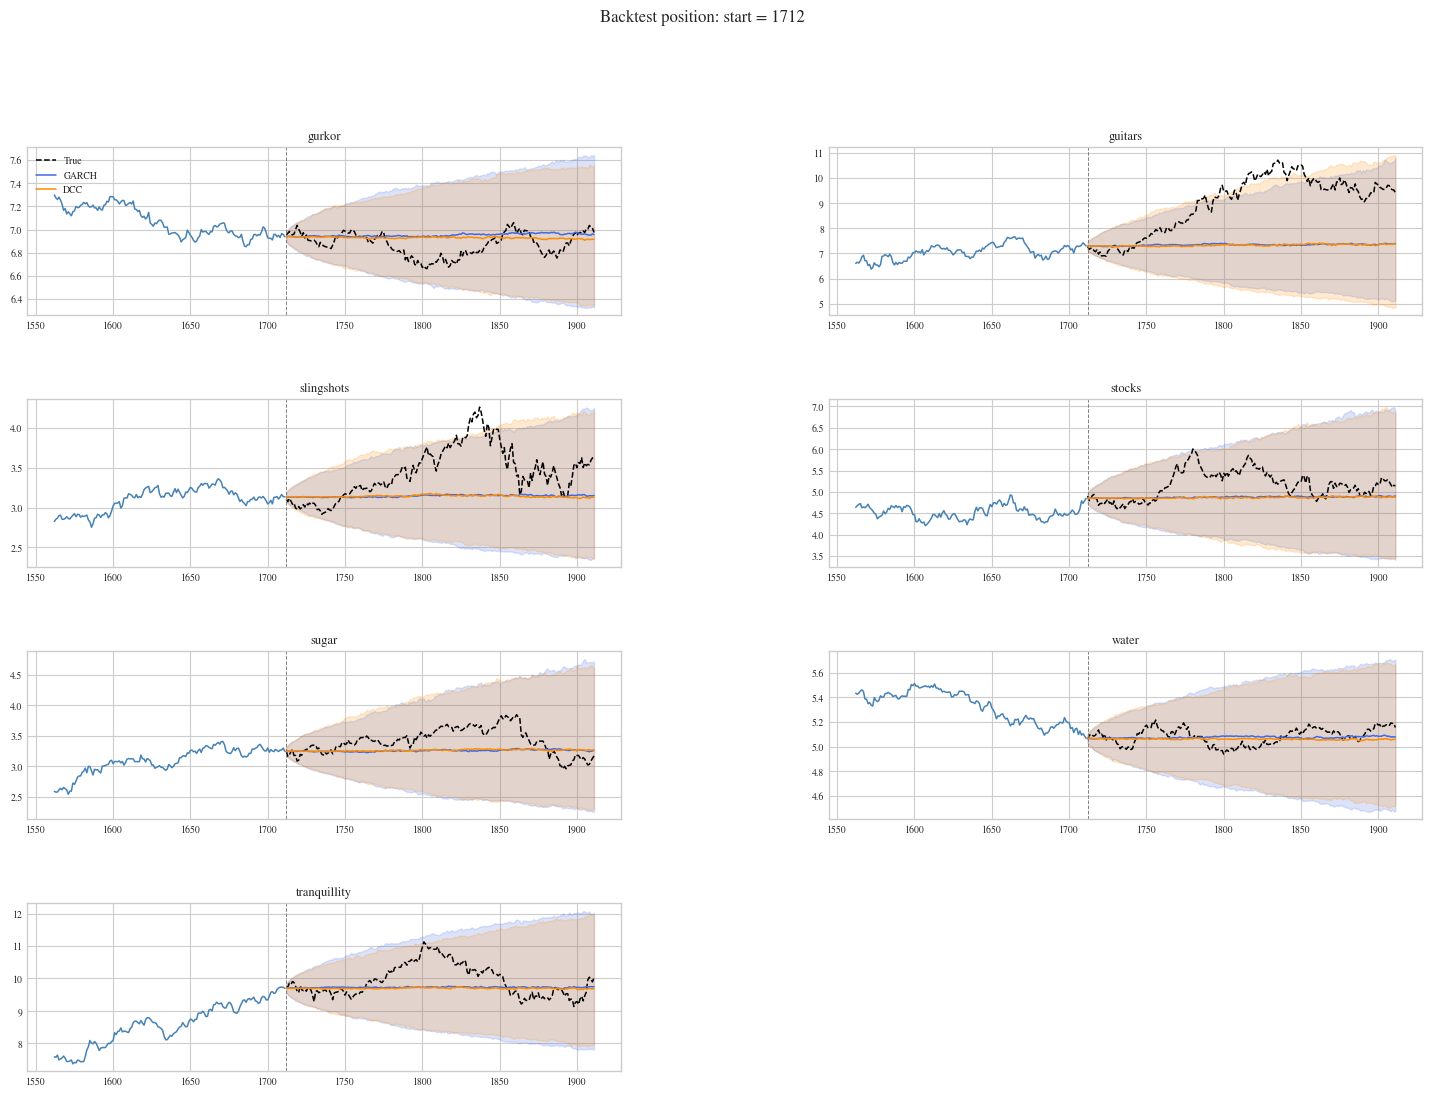

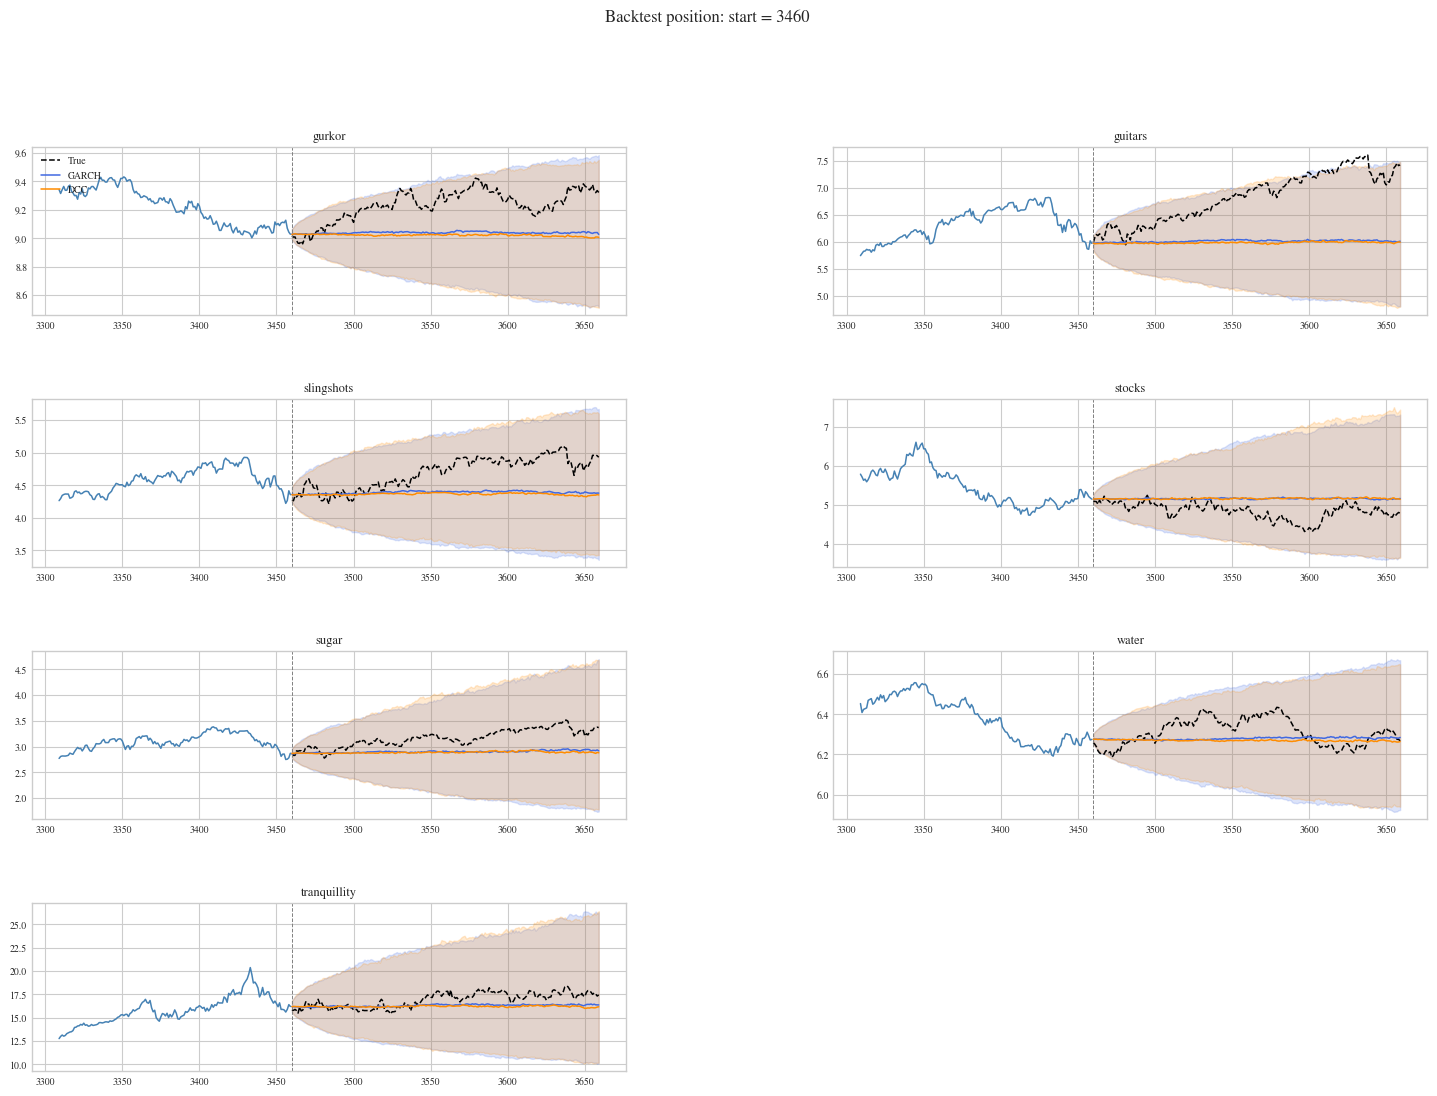

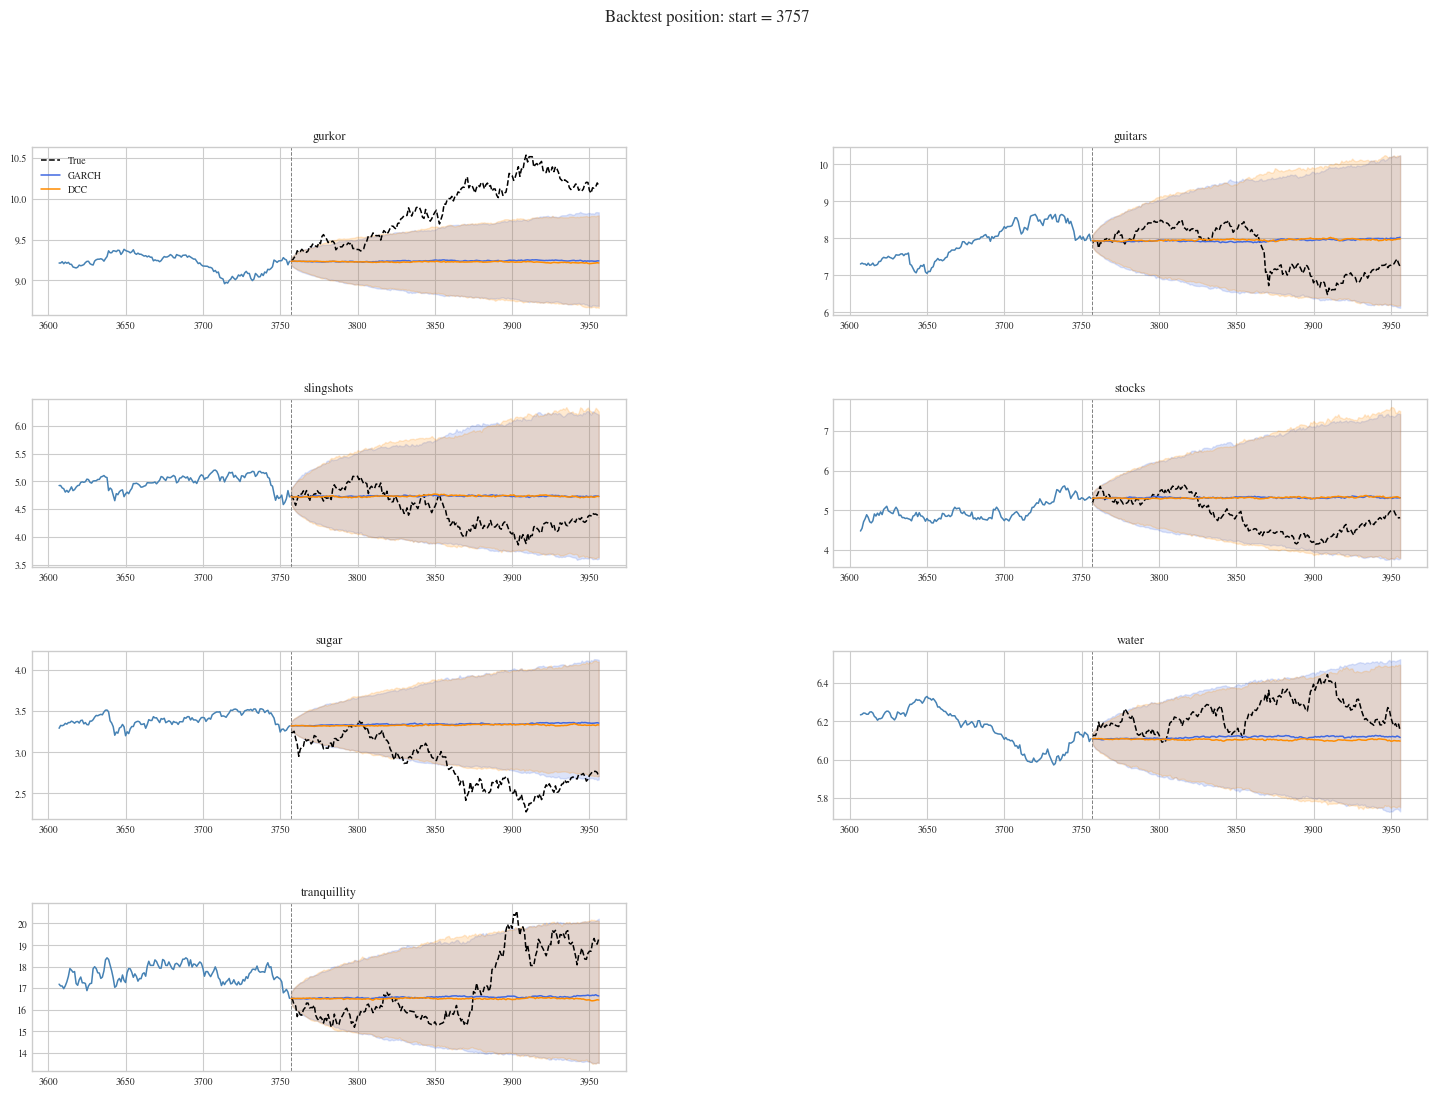

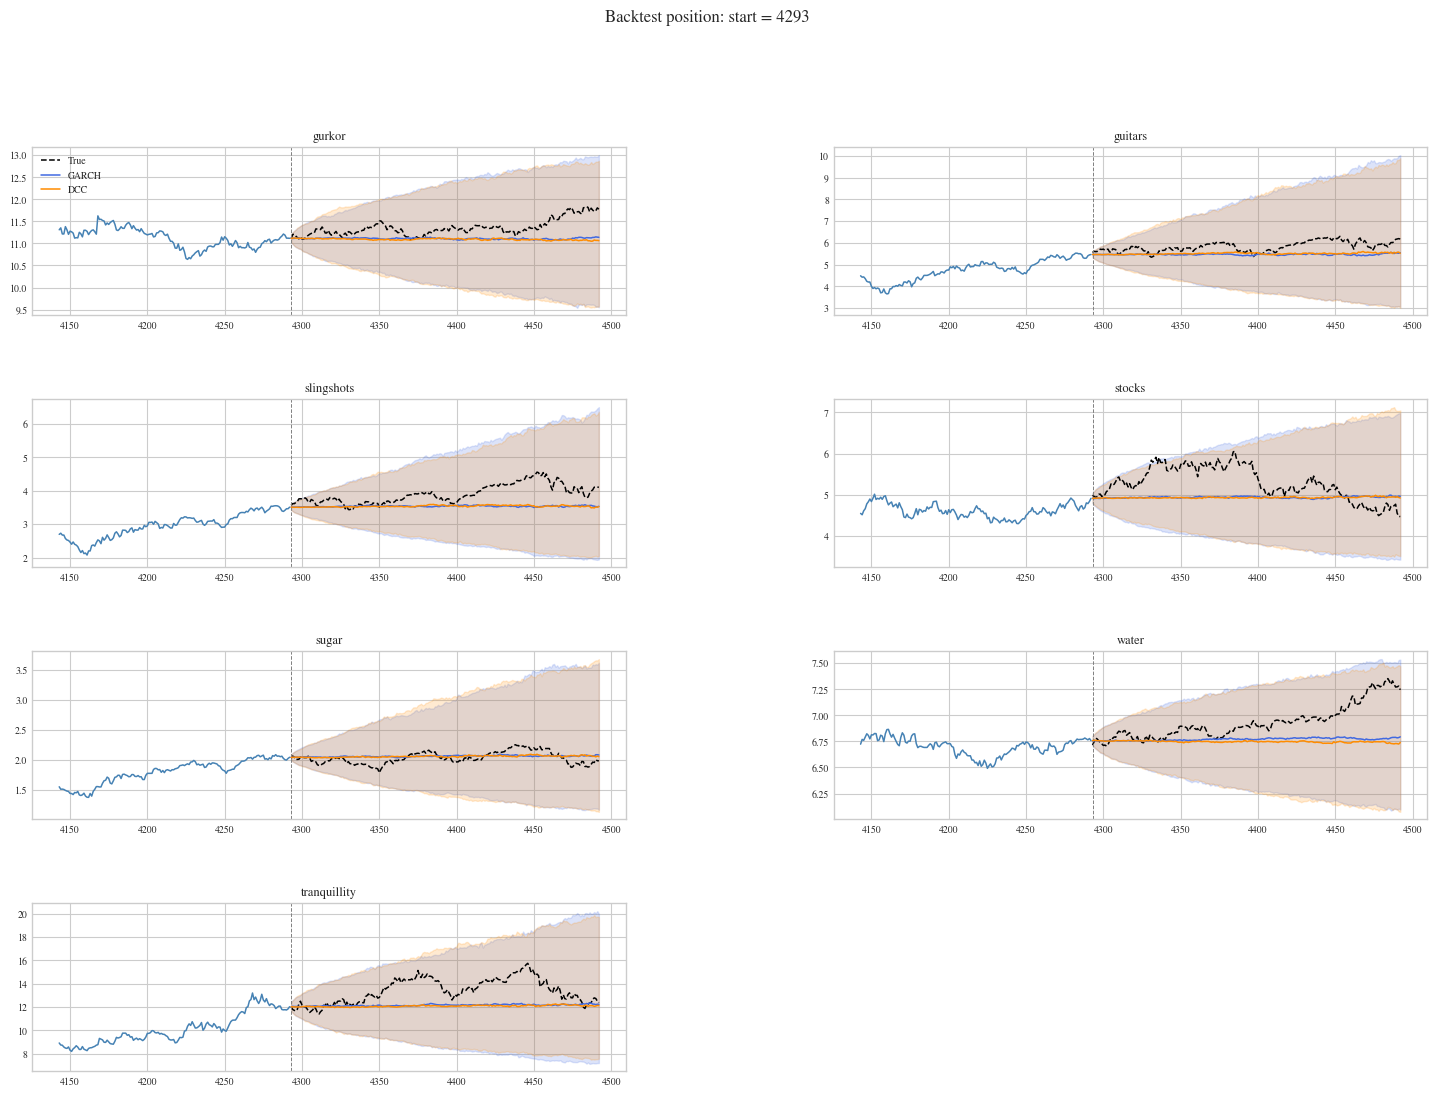

In [12]:
import matplotlib.gridspec as gridspec

N_VIZ       = 4      # backtest positions to visualise
N_STEPS_VIZ = N_STEPS
CAL_WINDOW  = 300
HISTORY     = 150    # observed days shown left of the pseudo-gap

series_names = list(prices.columns)
k            = len(series_names)

rng_viz      = np.random.default_rng(77)
min_last_obs = min(
    int(prices[s].dropna().index[-N_STEPS_VIZ - 1]) for s in series_names
)
candidates_viz = prices.index[(prices.index >= 1500) & (prices.index <= min_last_obs)]
viz_starts     = np.sort(rng_viz.choice(candidates_viz, size=N_VIZ, replace=False))

for start in viz_starts:
    # ── True prices & realized correlation during the pseudo-gap ──────────
    truth = {
        s: prices[s].dropna()[prices[s].dropna().index >= start].iloc[:N_STEPS_VIZ].values
        for s in series_names
    }
    true_lr_mat = np.stack(
        [np.diff(np.log(truth[s])) for s in series_names]
    )  # (k, N_STEPS_VIZ - 1)
    true_corr = np.corrcoef(true_lr_mat)

    # ── Pre-gap calibration-window correlation (baseline reference) ───────
    all_lr   = np.log(prices / prices.shift(1))
    pre_lr   = all_lr[all_lr.index < start].dropna().iloc[-CAL_WINDOW:]
    pre_corr = np.corrcoef(pre_lr.values.T)

    # ── Run both methods ──────────────────────────────────────────────────
    garch_res = {
        s: garch_extrapolation(
            prices[s], start_day=int(start), n_steps=N_STEPS_VIZ,
            calibration_window=CAL_WINDOW, n_simulations=1000, random_seed=0,
        )
        for s in series_names
    }
    dcc_res, _ = dcc_garch_extrapolation(
        prices, start_day=int(start), n_steps=N_STEPS_VIZ,
        calibration_window=CAL_WINDOW, n_simulations=1000, random_seed=0,
    )

    # ── Imputed correlation: average step-wise corr of DCC simulated lr ───
    # Stack (n_sims, N_STEPS_VIZ, k), compute log-returns, avg corr over steps
    all_paths   = np.stack([dcc_res[s]["simulations"] for s in series_names], axis=2)
    anchor_logs = np.array([
        np.log(float(prices[s].dropna()[prices[s].dropna().index < start].iloc[-1]))
        for s in series_names
    ])
    step0_lr = np.log(all_paths[:, 0, :]) - anchor_logs[None, :]       # (n_sims, k)
    rest_lr  = np.diff(np.log(all_paths), axis=1)                       # (n_sims, N_STEPS_VIZ-1, k)
    sim_lr   = np.concatenate([step0_lr[:, None, :], rest_lr], axis=1) # (n_sims, N_STEPS_VIZ, k)

    imputed_corr = np.mean(
        [np.corrcoef(sim_lr[:, h, :].T) for h in range(N_STEPS_VIZ)], axis=0
    )

    # ── Layout: fan plots on left, 3 heatmaps on right ────────────────────
    # subplot_mosaic: 4 rows × 2 cols of fans (8 cells, 7 used) | 3 heatmaps stacked
    mosaic = [
        ["f0", "f1"],
        ["f2", "f3"],
        ["f4", "f5"],
        ["f6", "." ],
    ]
    fig, axd = plt.subplot_mosaic(
        mosaic, figsize=(18, 12),
        gridspec_kw={
            "wspace": 0.35, "hspace": 0.5,
            "width_ratios": [1, 1],
            "height_ratios": [1, 1,1,1],
        },
    )
    #axd["."].set_visible(False)

    # Fan plots
    fan_keys = [f"f{i}" for i in range(k)]
    for i, s in enumerate(series_names):
        ax  = axd[fan_keys[i]]
        obs = prices[s].dropna()

        obs_tail  = obs[obs.index < start].iloc[-HISTORY:]
        true_tail = obs[obs.index >= start].iloc[:N_STEPS_VIZ]
        gap_idx   = dcc_res[s]["gap_index"]

        ax.plot(obs_tail.index,  obs_tail.values,  color="steelblue",  lw=1.1)
        ax.plot(true_tail.index, true_tail.values, color="black",      lw=1.1, ls="--", label="True")
        ax.axvline(x=start, color="grey", lw=0.7, ls="--")

        # GARCH fan
        pg = garch_res[s]["percentiles"]
        ax.fill_between(gap_idx, pg["p5"], pg["p95"], alpha=0.18, color="royalblue")
        ax.plot(gap_idx, garch_res[s]["median"], color="royalblue", lw=1.1, label="GARCH")

        # DCC fan
        pd_ = dcc_res[s]["percentiles"]
        ax.fill_between(gap_idx, pd_["p5"], pd_["p95"], alpha=0.18, color="darkorange")
        ax.plot(gap_idx, dcc_res[s]["median"], color="darkorange", lw=1.1, label="DCC")

        ax.set_title(s, fontsize=9)
        ax.tick_params(labelsize=7)
        if i == 0:
            ax.legend(fontsize=7, loc="upper left")

    
    fig.suptitle(f"Backtest position: start = {start}", fontsize=12, y=0.995)
    plt.show()